<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/MLP_and_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras import optimizers
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pandas as pd
from tensorflow.keras.constraints import max_norm

fashion_mnist = keras.datasets.fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

weight_decay = 1e-4

In [ ]:
model = models.Sequential([
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32, 3, padding="same", use_bias=False, activation=None, kernel_constraint=max_norm(3., axis=[0,1,2])),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(32, 3, padding="same", use_bias=False, activation=None, kernel_constraint=max_norm(3., axis=[0,1,2])),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, padding="same", use_bias=False, activation=None, kernel_constraint=max_norm(3., axis=[0,1,2])),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(64, 3, padding="same", use_bias=False, activation=None, kernel_constraint=max_norm(3., axis=[0,1,2])),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(2),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    # Flatten to feed MLP
    layers.Flatten(),

    # MLP classifier
    layers.Dense(256, activation="gelu"),
    layers.Dropout(0.30),
    layers.Dense(128, activation="gelu"),
    layers.Dropout(0.35),
    layers.Dense(64, activation="gelu"),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax")

    # layers.Dense(256, activation="elu", kernel_regularizer=regularizers.l2(weight_decay), kernel_initializer="he_normal",  kernel_constraint=max_norm(3.)),
    # layers.Dropout(0.5),

    # layers.Dense(128, activation="elu", kernel_regularizer=regularizers.l2(weight_decay), kernel_initializer="he_normal",  kernel_constraint=max_norm(3.)),
    # layers.Dropout(0.5),

    # layers.Dense(10, activation="softmax")
])

In [ ]:
callbacks = [
    ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=3, verbose=1, min_lr=1e-5),
    EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True, verbose=1)
  ]

optimizer = optimizers.Nadam(learning_rate=1e-3)

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

X_train = X_train[..., None]
X_valid = X_valid[..., None]
X_test  = X_test[..., None]

history = model.fit(X_train, y_train, epochs=80, validation_data=(X_valid, y_valid), callbacks=callbacks, batch_size=128)

Epoch 1/80
430/430 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.6005 - loss: 1.1420 - val_accuracy: 0.6936 - val_loss: 0.7959 - learning_rate: 0.0010
Epoch 2/80
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8434 - loss: 0.4785 - val_accuracy: 0.8868 - val_loss: 0.3155 - learning_rate: 0.0010
Epoch 3/80
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8709 - loss: 0.3953 - val_accuracy: 0.9096 - val_loss: 0.2630 - learning_rate: 0.0010
Epoch 4/80
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8860 - loss: 0.3447 - val_accuracy: 0.9116 - val_loss: 0.2585 - learning_rate: 0.0010
Epoch 5/80
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8971 - loss: 0.3218 - val_accuracy: 0.9106 - val_loss: 0.2617 - learning_rate: 0.0010
Epoch 6/80
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9024 - loss: 0.3091 - val_accuracy: 0.9202 - val_loss: 0.2415 - learning_rate: 0.0010
Epoch 7/80
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9070 - loss: 0

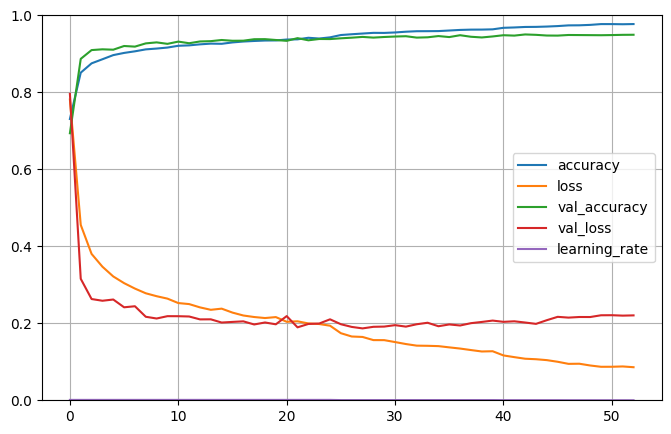

In [ ]:
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
# save_fig("keras_learning_curves_plot")
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9419 - loss: 0.2490


[0.24579361081123352, 0.9426000118255615]